# Smart Irrigation – Week 1

**Name:** Keerthi Bandari  
**Internship ID:** INTERNSHIP_1748923002683e727a876ea  
**Date:** 16 July 2025

In [9]:
import pandas as pd
df = pd.read_csv("irrigation_machine.csv")
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)
df.reset_index(drop=True, inplace=True)
print(df.columns.tolist())


['sensor_0', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'parcel_0', 'parcel_1', 'parcel_2']


In [10]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


try:
    df = pd.read_csv("irrigation_machine.csv")
    print("Sample data:")
    print(df.head())
except FileNotFoundError:
    print("Dataset not found. Please place 'irrigation_machine.csv' in the same folder.")

Sample data:
   Unnamed: 0  sensor_0  sensor_1  sensor_2  sensor_3  sensor_4  sensor_5  \
0           0       1.0       2.0       1.0       7.0       0.0       1.0   
1           1       5.0       1.0       3.0       5.0       2.0       2.0   
2           2       3.0       1.0       4.0       3.0       4.0       0.0   
3           3       2.0       2.0       4.0       3.0       5.0       0.0   
4           4       4.0       3.0       3.0       2.0       5.0       1.0   

   sensor_6  sensor_7  sensor_8  sensor_9  sensor_10  sensor_11  sensor_12  \
0       1.0       4.0       0.0       3.0        1.0        3.0        6.0   
1       1.0       2.0       3.0       1.0        3.0        2.0        2.0   
2       1.0       6.0       0.0       2.0        3.0        2.0        4.0   
3       3.0       2.0       2.0       5.0        3.0        1.0        2.0   
4       3.0       1.0       1.0       2.0        4.0        5.0        3.0   

   sensor_13  sensor_14  sensor_15  sensor_16  sensor_1

In [11]:
X = df.iloc[:, 0:20]    
y = df.iloc[:, 20:23]   

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("\nX Columns:", X.columns.tolist())
print("y Columns:", y.columns.tolist())


Shape of X: (2000, 20)
Shape of y: (2000, 3)

X Columns: ['Unnamed: 0', 'sensor_0', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18']
y Columns: ['sensor_19', 'parcel_0', 'parcel_1']


In [12]:
X.sample(10)

,Unnamed: 0,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18
783,783,1.0,1.0,5.0,1.0,1.0,3.0,5.0,2.0,2.0,1.0,4.0,5.0,7.0,1.0,2.0,1.0,4.0,3.0,1.0
1854,1854,1.0,1.0,4.0,0.0,3.0,1.0,9.0,8.0,0.0,3.0,1.0,4.0,4.0,3.0,2.0,0.0,3.0,7.0,1.0
1845,1845,0.0,1.0,5.0,4.0,4.0,4.0,4.0,3.0,2.0,3.0,3.0,1.0,2.0,2.0,3.0,0.0,3.0,2.0,1.0
1642,1642,1.0,1.0,1.0,1.0,2.0,0.0,3.0,5.0,0.0,1.0,8.0,6.0,7.0,6.0,3.0,1.0,1.0,1.0,3.0
692,692,0.0,1.0,1.0,4.0,3.0,1.0,1.0,2.0,0.0,2.0,5.0,2.0,4.0,1.0,5.0,0.0,1.0,0.0,3.0
1262,1262,1.0,2.0,1.0,0.0,3.0,1.0,4.0,7.0,0.0,2.0,5.0,1.0,9.0,3.0,3.0,0.0,5.0,0.0,3.0
581,581,0.0,1.0,1.0,3.0,1.0,1.0,2.0,6.0,1.0,4.0,2.0,4.0,9.0,4.0,9.0,1.0,4.0,0.0,6.0
107,107,1.0,2.0,3.0,3.0,2.0,1.0,3.0,6.0,2.0,2.0,1.0,3.0,1.0,2.0,3.0,2.0,6.0,4.0,2.0
424,424,1.0,1.0,4.0,2.0,2.0,0.0,2.0,3.0,2.0,4.0,5.0,3.0,7.0,4.0,9.0,0.0,3.0,1.0,2.0
1772,1772,1.0,0.0,3.0,2.0,2.0,1.0,5.0,5.0,2.0,3.0,6.0,6.0,5.0,2.0,6.0,1.0,0.0,1.0,3.0


In [13]:
y.sample(10)

,sensor_19,parcel_0,parcel_1
1702,4.0,0,0
1358,1.0,1,1
1877,0.0,0,1
648,3.0,0,0
545,0.0,1,0
465,0.0,1,1
752,0.0,1,0
976,1.0,1,1
197,1.0,0,0
1705,3.0,1,1


In [14]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2000 non-null   int64  
 1   sensor_0    2000 non-null   float64
 2   sensor_1    2000 non-null   float64
 3   sensor_2    2000 non-null   float64
 4   sensor_3    2000 non-null   float64
 5   sensor_4    2000 non-null   float64
 6   sensor_5    2000 non-null   float64
 7   sensor_6    2000 non-null   float64
 8   sensor_7    2000 non-null   float64
 9   sensor_8    2000 non-null   float64
 10  sensor_9    2000 non-null   float64
 11  sensor_10   2000 non-null   float64
 12  sensor_11   2000 non-null   float64
 13  sensor_12   2000 non-null   float64
 14  sensor_13   2000 non-null   float64
 15  sensor_14   2000 non-null   float64
 16  sensor_15   2000 non-null   float64
 17  sensor_16   2000 non-null   float64
 18  sensor_17   2000 non-null   float64
 19  sensor_18   2000 non-null  

In [15]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sensor_19  2000 non-null   float64
 1   parcel_0   2000 non-null   int64  
 2   parcel_1   2000 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 47.0 KB


In [16]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2000, 20)
Shape of y: (2000, 3)


# Week 2 – Smart Irrigation Project
## Pump Status Analysis & Visualization

This notebook contains the implementation and visualization of pump activity across different farm parcels using Python and Matplotlib, as part of the Week 2 submission for the Smart Irrigation internship project.

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[0.125     , 0.22222222, 0.1       , ..., 0.09090909, 0.9       ,
        0.28571429],
       [0.625     , 0.11111111, 0.3       , ..., 0.18181818, 0.2       ,
        1.        ],
       [0.375     , 0.11111111, 0.4       , ..., 0.27272727, 0.1       ,
        0.        ],
       ...,
       [0.125     , 0.33333333, 0.3       , ..., 0.36363636, 0.1       ,
        0.        ],
       [0.25      , 0.11111111, 0.        , ..., 0.        , 0.3       ,
        0.        ],
       [0.        , 0.11111111, 0.4       , ..., 0.45454545, 0.2       ,
        0.14285714]], shape=(2000, 20))

In [19]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [20]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1600, 20), (400, 20), (1600, 3), (400, 3))

In [21]:
# Train Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier

#Custom hypeparameters for RandomForest
rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

# Wrap it with  MultiOutoutClassifier
model = MultiOutputClassifier(rf)

# Train the model
model.fit(X_train, y_train)

MultiOutputClassifier(estimator=RandomForestClassifier(max_depth=10,
                                                       min_samples_leaf=2,
                                                       min_samples_split=4,
                                                       n_estimators=200,
                                                       random_state=42))

In [22]:
# Evaluate Model
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=y.columns))

Classification Report:
              precision    recall  f1-score   support

    parcel_0       0.87      0.93      0.90       256
    parcel_1       0.91      0.97      0.94       304
    parcel_2       0.93      0.48      0.64        87

   micro avg       0.89      0.89      0.89       647
   macro avg       0.90      0.80      0.83       647
weighted avg       0.90      0.89      0.88       647
 samples avg       0.82      0.79      0.79       647



c:\Users\Keerthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Keerthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Keerthi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [23]:
print(df[['parcel_0', 'parcel_1', 'parcel_2']].sum())

parcel_0    1271
parcel_1    1461
parcel_2     424
dtype: int64


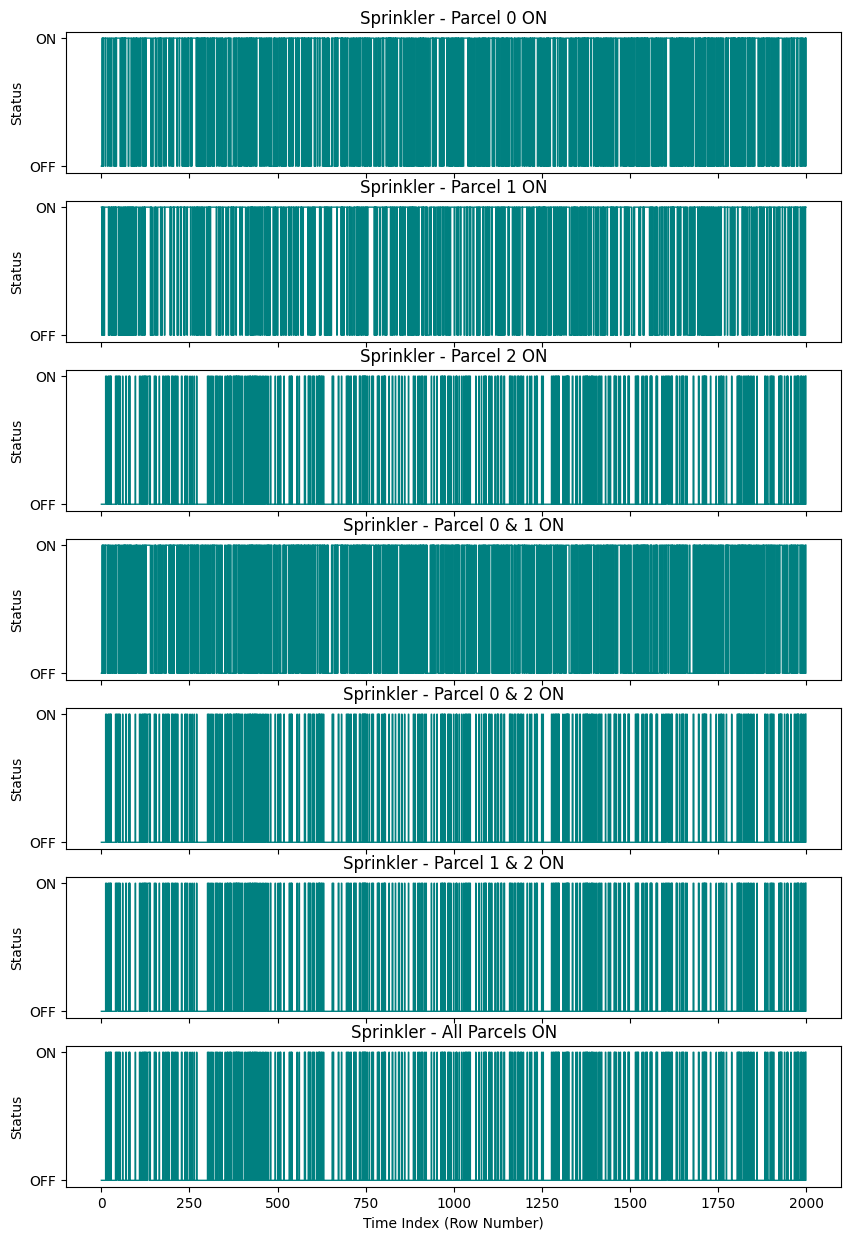

In [24]:
import matplotlib.pyplot as plt
#Define parcel activation conditions with descrptive labels
conditions = {
    "Parcel 0 ON": df['parcel_0'],
    "Parcel 1 ON": df['parcel_1'],
    "Parcel 2 ON": df['parcel_2'],
    "Parcel 0 & 1 ON": df['parcel_0'] & df['parcel_1'],
    "Parcel 0 & 2 ON": df['parcel_0'] & df['parcel_2'],
    "Parcel 1 & 2 ON": df['parcel_1'] & df['parcel_2'],
    "All Parcels ON": df['parcel_0'] & df['parcel_1'] & df['parcel_2']
}

# Create vertically stacked subplots (one for each condition)
fig, axs = plt.subplots(nrows=len(conditions), figsize=(10, 15), sharex=True)

# Loop through each condition to plot corresponding square wave
for ax, (title, condition) in zip(axs, conditions.items()):
    ax.step(df.index, condition.astype(int), where='post', linewidth=1, color='teal')
    ax.set_title(f"Sprinkler - {title}")
    ax.set_ylabel("Status")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['OFF', 'ON'])

# Label x-axis on the last subplot
axs[-1].set_xlabel("Time Index (Row Number)")

# Plot
plt.show()

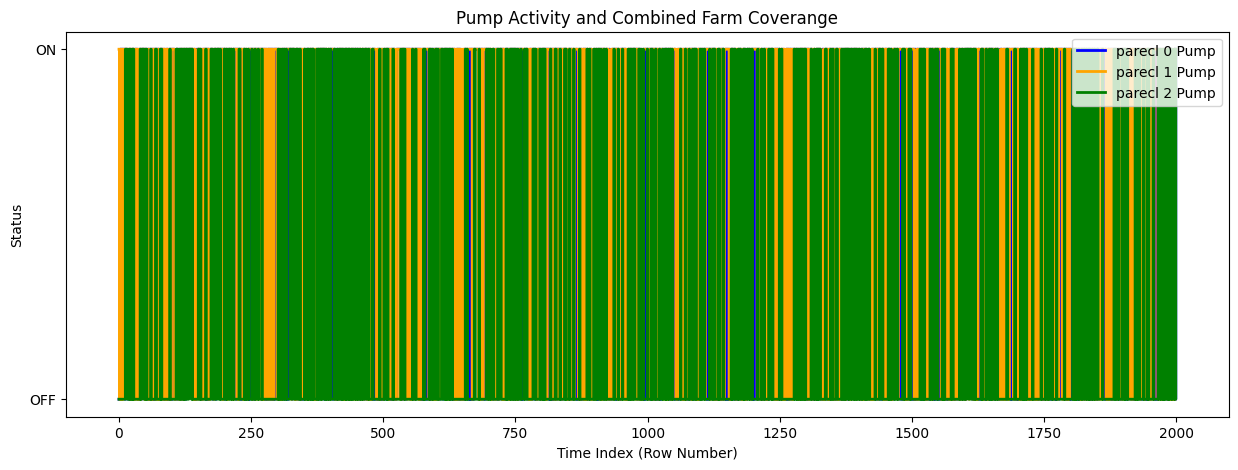

In [25]:
# Calculate combined activity of all pumps (overlap)
any_pump_on = (df['parcel_0'] == 1) | (df['parcel_1'] == 1) | (df['parcel_2'] == 1)

plt.figure(figsize=(15, 5))


# Plot individual pump statuses
plt.step(df.index, df['parcel_0'], where='post', linewidth=2, label='parecl 0 Pump', color='blue')
plt.step(df.index, df['parcel_1'], where='post', linewidth=2, label='parecl 1 Pump', color='orange')
plt.step(df.index, df['parcel_2'], where='post', linewidth=2, label='parecl 2 Pump', color='green')

plt.title("Pump Activity and Combined Farm Coverange")
plt.xlabel("Time Index (Row Number)")
plt.ylabel("Status")
plt.yticks([0, 1], ['OFF', 'ON'])
plt.legend(loc='upper right')
plt.show()

In [26]:
import joblib
from sklearn.pipeline import Pipeline
joblib.dump(model, "Farm_Irrigation_System.pkl")

['Farm_Irrigation_System.pkl']